In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet('../datasets/modelling_dataset.parquet')

In [3]:
df.head()

,Time_Stamp,Year,Hour,Day_of_Week,Month,Weekend,Holiday,Zone_Int_ID,Amenity,Crossing,...,Wind_Speed(mph),Precipitation(in),Weather_Clear,Weather_Cloudy,Weather_Dust/Windy,Weather_Rain/Drizzle,Weather_Snow/Ice,Weather_Stormy,Weather_Visibility Issues,Accident_Count
0,2016-06-14 20:00:00,2016,20,1,6,0,0,0,0.041169,0.233068,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,2016-06-14 20:00:00,2016,20,1,6,0,0,1,0.030181,0.424547,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2016-06-14 20:00:00,2016,20,1,6,0,0,2,0.000000,0.316667,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2016-06-14 20:00:00,2016,20,1,6,0,0,3,0.000000,0.161290,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2016-06-14 20:00:00,2016,20,1,6,0,0,4,0.000000,0.021277,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


# Approach

In this cell, I am employing a 2 Step Approach Using Random Forest

### Step 1: RF Classifier

Train an RF Classifier on entire dataset to predict a binary target: $0$ (No Accident) vs. $1$ (At least one accident)

### Step 2: RF Regressor

Filter dataset to only include rows where Accident_Count > 0. Train an RF Regressor on this subset to predict the exact count ($1, 2, 3, \dots, 105$).

### Step 3: Adding Models Together

Model A gives $P(\text{Accident})$. Model B gives $E[\text{Count} \mid \text{Accident}]$. Multiply them together to get  final "Expected Risk Score."

## STEP 1: RF Classifier

In [4]:
# Creating a binary target variable for accident occurrence to use as target
df["Is_Accident"] = (df["Accident_Count"] > 0).astype(int)

In [5]:
# Looking at where to split the time series data for training, validation, and testing
split_70 = df['Time_Stamp'].quantile(0.70)
split_85 = df['Time_Stamp'].quantile(0.85)

print(f"70% split: {split_70}")
print(f"85% split: {split_85}")

70% split: 2021-03-16 12:00:00
85% split: 2022-03-23 10:00:00


In [6]:
# Creating the datasers for training, validation, and testing based on the time splits
train_df = df[df['Time_Stamp'] < split_70].copy()
val_df = df[(df['Time_Stamp'] >= split_70) & (df['Time_Stamp'] < split_85)].copy()
test_df = df[df['Time_Stamp'] >= split_85].copy()

# Verifying the sizes of the datasets
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Testing set size: {len(test_df)}")

Training set size: 3290824
Validation set size: 705154
Testing set size: 705312


In [7]:
# Subsampling the training set to provide more balance to the classes

accidents = train_df[train_df['Is_Accident'] == 1]
non_accidents = train_df[train_df['Is_Accident'] == 0]

non_accidents_sampled = non_accidents.sample(n=len(accidents) * 5, random_state=42)

train_subsampled = pd.concat([accidents, non_accidents_sampled]).sample(frac=1, random_state=42)

print(f"Subsampled training set size: {len(train_subsampled)}")

Subsampled training set size: 782226


In [8]:
# Having the predictor features for the model excluding year and time stamp
features = ['Hour', 'Day_of_Week', 'Month', 'Weekend', 'Holiday', 
            'Zone_Int_ID', 'Amenity', 'Crossing', 'Wind_Speed(mph)', 
            'Precipitation(in)', 'Weather_Clear', 'Weather_Cloudy', 
            'Weather_Dust/Windy', 'Weather_Rain/Drizzle', 'Weather_Snow/Ice', 
            'Weather_Stormy', 'Weather_Visibility Issues']

# Creating X and y for the training, validation, and test sets for classification model
X_train_classifier = train_subsampled[features]
y_train_classifier = train_subsampled['Is_Accident']

X_val_classifier = val_df[features]
y_val_classifier = val_df['Is_Accident']

X_test_classifier = test_df[features]
y_test_classifier = test_df['Is_Accident']

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Training the model on the subsetted training data

classifier_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=5,
    class_weight= {0: 1, 1:5},  # equivalent to scale_pos_weight
    max_features=0.8,       # equivalent to colsample_bytree
    max_samples=0.8,
    n_jobs=-1,
    random_state=42
)

classifier_model.fit(X_train_classifier, y_train_classifier)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.8
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

# Evaluating the initial model on the validation set 
y_val_preds = classifier_model.predict(X_val_classifier)
y_val_pred_proba = classifier_model.predict_proba(X_val_classifier)[:, 1]

# Checking metrics
print("Classification Report:")
print(classification_report(y_val_classifier, y_val_preds))

print("Confusion Matrix:")
print(confusion_matrix(y_val_classifier, y_val_preds))

print(f"ROC AUC Score: {roc_auc_score(y_val_classifier, y_val_pred_proba):.4f}")

print(f"Average Precision Score: {average_precision_score(y_val_classifier, y_val_pred_proba)}")


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.65      0.78    665539
           1       0.13      0.91      0.23     39615

    accuracy                           0.66    705154
   macro avg       0.56      0.78      0.51    705154
weighted avg       0.94      0.66      0.75    705154

Confusion Matrix:
[[432099 233440]
 [  3662  35953]]
ROC AUC Score: 0.8475
Average Precision Score: 0.19447901407471196


In [12]:
import numpy as np
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import fbeta_score, make_scorer

X_tuning_classifier = pd.concat([X_train_classifier, X_val_classifier])
y_tuning_classifier = pd.concat([y_train_classifier, y_val_classifier])

# Identifying which is used for training (-1) and which is used for validation(0)
split_index = np.full(X_tuning_classifier.shape[0], -1)
split_index[len(train_subsampled):] = 0
pds = PredefinedSplit(test_fold=split_index)

# GridSearchCV parameters
param_grid = {
    'max_depth':        [5, 7, 10],
    'n_estimators':     [150, 200, 300]
}

# Use f2 to prioritize recall while still considering precision
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
    param_grid=param_grid,
    cv=pds,
    scoring="average_precision",  
    verbose=2
)

grid_search.fit(X_tuning_classifier, y_tuning_classifier)

best_classifier = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 1 folds for each of 9 candidates, totalling 9 fits
[CV] END ......................max_depth=5, n_estimators=150; total time=  22.2s
[CV] END ......................max_depth=5, n_estimators=200; total time=  29.9s
[CV] END ......................max_depth=5, n_estimators=300; total time=  44.7s
[CV] END ......................max_depth=7, n_estimators=150; total time=  30.6s
[CV] END ......................max_depth=7, n_estimators=200; total time=  39.2s
[CV] END ......................max_depth=7, n_estimators=300; total time=  58.6s
[CV] END .....................max_depth=10, n_estimators=150; total time=  39.4s
[CV] END .....................max_depth=10, n_estimators=200; total time=  51.1s
[CV] END .....................max_depth=10, n_estimators=300; total time= 1.3min
Best Parameters: {'max_depth': 10, 'n_estimators': 200}


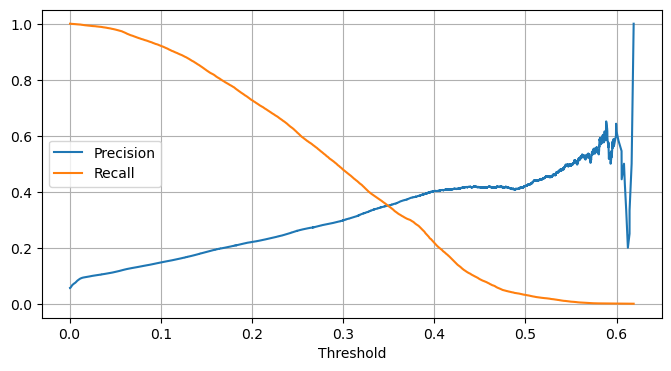

In [13]:
# Determining Optimal Threshold for Classification
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Using the best classifier on the validation set
y_val_probs = best_classifier.predict_proba(val_df[features])[:, 1]
precision, recall, thresholds = precision_recall_curve(val_df['Is_Accident'], y_val_probs)

# Plotting precision recall curve for visual analysis
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Testing final model on test dataset
y_test_pred_proba = best_classifier.predict_proba(X_test_classifier)[:, 1]

# Use a 0.3 threshold based on above precision-recall curve analysis 
y_test_preds = (y_test_pred_proba >= 0.2).astype(int)

# Checking metrics
print("Classification Report:")
print(classification_report(y_test_classifier, y_test_preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test_classifier, y_test_preds))

print(f"ROC AUC Score: {roc_auc_score(y_test_classifier, y_test_pred_proba):.4f}")

print(f"Average Precision Score: {average_precision_score(y_test_classifier, y_test_pred_proba)}")


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.84      0.91    670990
           1       0.18      0.69      0.29     34322

    accuracy                           0.84    705312
   macro avg       0.58      0.77      0.60    705312
weighted avg       0.94      0.84      0.88    705312

Confusion Matrix:
[[565848 105142]
 [ 10477  23845]]
ROC AUC Score: 0.8704
Average Precision Score: 0.23941999815376536


## STEP 2: RF Regressor

In [15]:
# Looking at only accidents to train regression model
train_accidents = train_df[train_df['Is_Accident'] == 1].copy()
val_accidents = val_df[val_df['Is_Accident'] == 1].copy()

X_train_regressor = train_accidents[features]
y_train_regressor = train_accidents['Accident_Count'] # Use accident count as target for regression model

X_val_regressor = val_accidents[features]
y_val_regressor = val_accidents['Accident_Count']

# Using log of values to remove large outliers
y_train_log = np.log1p(y_train_regressor) 
y_val_log = np.log1p(y_val_regressor)

In [17]:
# Doing hyperparameter tuning for regression model using the same predefined split as classification model 

from sklearn.ensemble import RandomForestRegressor

X_tuning_regressor = pd.concat([X_train_regressor, X_val_regressor])
y_tuning_regressor = pd.concat([y_train_regressor, y_val_regressor])
y_tuning_log = pd.concat([y_train_log, y_val_log])

split_index_b = np.full(X_tuning_regressor.shape[0], -1)
split_index_b[len(train_accidents):] = 0
pds_b = PredefinedSplit(test_fold=split_index_b)

param_grid_regressor = {
    'max_depth':       [6, 8, 10],
    'n_estimators':    [100, 200, 300],
}

grid_search_regressor = GridSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
    param_grid=param_grid_regressor,
    cv=pds_b,
    scoring='neg_mean_absolute_error', 
    verbose=2
)

grid_search_regressor.fit(X_tuning_regressor, y_tuning_log)
best_regressor = grid_search_regressor.best_estimator_
print(f"Best Regressor Parameters: {grid_search_regressor.best_params_}")

Fitting 1 folds for each of 9 candidates, totalling 9 fits
[CV] END ......................max_depth=6, n_estimators=100; total time=   4.0s
[CV] END ......................max_depth=6, n_estimators=200; total time=  10.6s
[CV] END ......................max_depth=6, n_estimators=300; total time=  15.0s
[CV] END ......................max_depth=8, n_estimators=100; total time=   6.5s
[CV] END ......................max_depth=8, n_estimators=200; total time=  12.6s
[CV] END ......................max_depth=8, n_estimators=300; total time=  19.6s
[CV] END .....................max_depth=10, n_estimators=100; total time=   8.0s
[CV] END .....................max_depth=10, n_estimators=200; total time=  15.8s
[CV] END .....................max_depth=10, n_estimators=300; total time=  23.2s
Best Regressor Parameters: {'max_depth': 8, 'n_estimators': 200}


In [18]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Evaluating the best regression model on the validation set of accidents
y_val_log_preds = best_regressor.predict(val_accidents[features])
y_val_final_preds = np.expm1(y_val_log_preds)

# Calculating evaluation metrics
mae = mean_absolute_error(val_accidents['Accident_Count'], y_val_final_preds)
rmse = root_mean_squared_error(val_accidents['Accident_Count'], y_val_final_preds)
r2 = r2_score(val_accidents['Accident_Count'], y_val_final_preds)

print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 1.461384540355099
Root Mean Squared Error: 3.847504609481833
R-squared: 0.042365470246164105


## STEP 3: Final Synthesis

In [19]:
# Using the classifier to predict the probability of accident on test
test_probs = best_classifier.predict_proba(X_test_classifier)[:, 1]
test_preds = (test_probs >= 0.4).astype(int)

# Using the regressor to predict the numbver of accidents on test
test_log_severity = best_regressor.predict(X_test_classifier)
test_severity = np.expm1(test_log_severity)


final_results = test_df.copy() 
final_results['Prob_Accident'] = test_probs
final_results['Predicted_Accident'] = test_preds
final_results['Expected_Severity'] = test_severity

# Creating the final risk score by multiplying the probability of an accident occurring with the expected number of accidents
final_results['Risk_Score'] = test_probs * test_severity
final_results["Risk_Score_2"] = test_preds * test_severity

## STEP 4: Visualizing Results

#### Looking at the actual accidents in the test set

In [20]:
import plotly.express as px
import h3

# Aggregate actual accident counts from test set by zone
miami_test = final_results[final_results['City_Miami'] == 1].copy()

zone_accidents = miami_test.groupby('Zone_ID')['Accident_Count'].sum().reset_index()
zone_accidents.rename(columns={'Accident_Count': 'Total_Accidents'}, inplace=True)

# Build GeoJSON from H3 zone IDs
features = []
for zone in zone_accidents['Zone_ID']:
    boundary = h3.cell_to_boundary(zone)
    coords = [[lon, lat] for lat, lon in boundary]
    coords.append(coords[0])
    features.append({
        'type': 'Feature',
        'id': zone,
        'properties': {},
        'geometry': {'type': 'Polygon', 'coordinates': [coords]}
    })

geojson = {'type': 'FeatureCollection', 'features': features}

# Plot the map
fig = px.choropleth_map(
    zone_accidents,
    geojson=geojson,
    locations='Zone_ID',
    featureidkey='id',
    color='Total_Accidents',
    color_continuous_scale='Reds',
    map_style='carto-positron',
    zoom=10,
    #center={'lat': 29.7604, 'lon': -95.3698},
    center={'lat': 25.7617, 'lon': -80.1918}, #for Miami
    title='Test Set: Actual Accident Counts by Zone',
    labels={'Total_Accidents': 'Accidents'}
)

fig.update_layout(margin={'r': 0, 't': 30, 'l': 0, 'b': 0})
fig.show()

In [21]:
import plotly.express as px
import h3

# Aggregate predicted risk scores from test set by zone
miami_test = final_results[final_results['City_Miami'] == 1].copy()

zone_risk = miami_test.groupby('Zone_ID')['Risk_Score'].mean().reset_index()
zone_risk.rename(columns={'Risk_Score': 'Total_Risk_Score'}, inplace=True)

# Build GeoJSON from H3 zone IDs
features = []
for zone in zone_risk['Zone_ID']:
    boundary = h3.cell_to_boundary(zone)
    coords = [[lon, lat] for lat, lon in boundary]
    coords.append(coords[0])
    features.append({
        'type': 'Feature',
        'id': zone,
        'properties': {},
        'geometry': {'type': 'Polygon', 'coordinates': [coords]}
    })

geojson = {'type': 'FeatureCollection', 'features': features}

# Plot the map
fig = px.choropleth_map(
    zone_risk,
    geojson=geojson,
    locations='Zone_ID',
    featureidkey='id',
    color='Total_Risk_Score',
    color_continuous_scale='Reds',
    map_style='carto-positron',
    zoom=10,
    #center={'lat': 29.7604, 'lon': -95.3698},
    center={'lat': 25.7617, 'lon': -80.1918}, #for Miami
    title='Test Set: Predicted Risk Score by Zone',
    labels={'Total_Risk_Score': 'Risk Score'}
)

fig.update_layout(margin={'r': 0, 't': 30, 'l': 0, 'b': 0})
fig.show()